# Quantum Gates (Qiskit) — Descriptions + Examples

This notebook shows common quantum gates with **(1) a short explanation** and **(2) a runnable Qiskit example**.

**Notes**
- A *quantum gate* is typically a **unitary** operation (reversible).
- Many **phase gates** (Z, S, T, P, Rz, CZ, …) do *not* change measurement probabilities in the Z-basis, but they *do* change the **statevector phase**. That’s why we print the statevector before measuring.
- For each example we: build a circuit (without measurement) → print the statevector → measure and simulate → plot a histogram.

In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from IPython.display import display
import numpy as np
import warnings
warnings.filterwarnings('ignore')

simulator = AerSimulator()

In [8]:
def statevector_of(qc: QuantumCircuit) -> Statevector:
    """Return statevector for the circuit (ignoring final measurements if present)."""
    try:
        qc_nom = qc.remove_final_measurements(inplace=False)
    except Exception:
        qc_nom = qc.copy()
    return Statevector.from_instruction(qc_nom)


def counts_from_circuit(qc: QuantumCircuit, shots: int = 1024):
    """Measure all qubits and return (measured_circuit, counts)."""
    qc_m = qc.copy()
    qc_m.measure_all()
    tqc = transpile(qc_m, simulator)
    result = simulator.run(tqc, shots=shots).result()
    return qc_m, result.get_counts()


def demo(qc: QuantumCircuit, title: str, shots: int = 2000, show_statevector: bool = True):
    print(f"\n=== {title} ===")
    if show_statevector:
        print('Statevector (before measurement):')
        print(statevector_of(qc))
    display(qc.draw('mpl'))
    qc_m, counts = counts_from_circuit(qc, shots=shots)
    print('Counts:', counts)
    display(qc_m.draw('mpl'))
    display(plot_histogram(counts))
    return counts

## 1-qubit gates

### Identity (I)
Does nothing: |0⟩ → |0⟩, |1⟩ → |1⟩.


=== I gate ===
Statevector (before measurement):
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


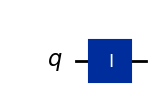

Counts: {'0': 2000}


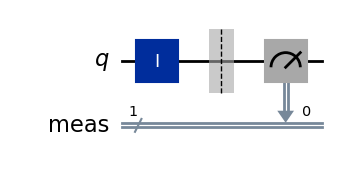

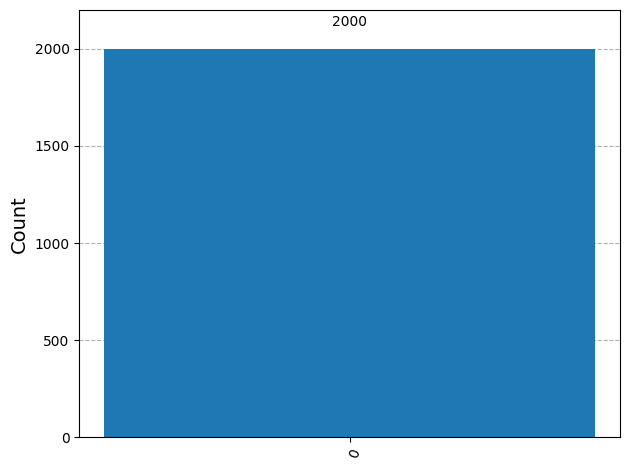

{'0': 2000}

In [9]:
qc = QuantumCircuit(1, name='I')
qc.id(0)
demo(qc, 'I gate')

### Pauli-X (NOT)
Bit-flip: |0⟩ ↔ |1⟩.


=== X gate ===
Statevector (before measurement):
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


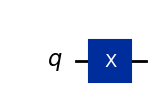

Counts: {'1': 2000}


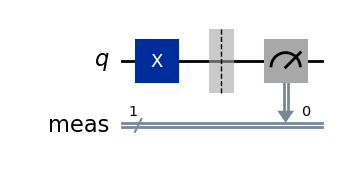

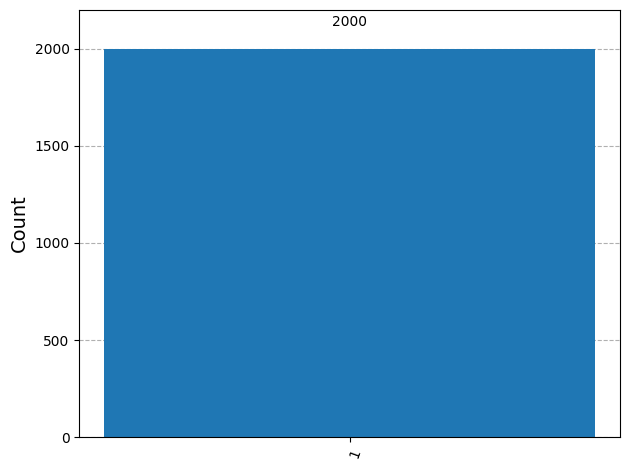

{'1': 2000}

In [10]:
qc = QuantumCircuit(1, name='X')
qc.x(0)
demo(qc, 'X gate')

### Pauli-Y
Bit-flip + phase: Y = iXZ. It flips |0⟩ ↔ |1⟩ with a relative phase.


=== Y gate ===
Statevector (before measurement):
Statevector([0.+0.j, 0.+1.j],
            dims=(2,))


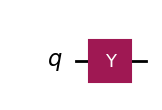

Counts: {'1': 2000}


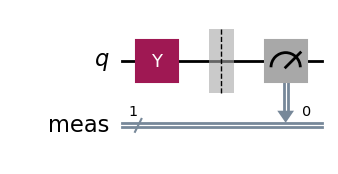

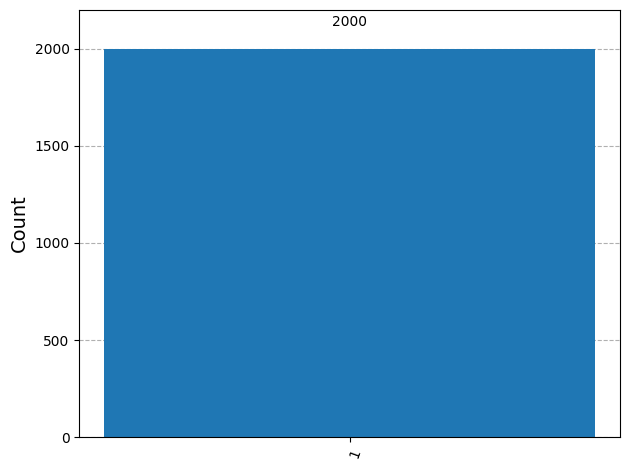

{'1': 2000}

In [11]:
qc = QuantumCircuit(1, name='Y')
qc.y(0)
demo(qc, 'Y gate')

### Pauli-Z
Phase-flip: Z|0⟩ = |0⟩, Z|1⟩ = −|1⟩. Measurement in the Z-basis looks unchanged unless you create superposition/interference.


=== Z gate acting on |1> (phase becomes -1) ===
Statevector (before measurement):
Statevector([ 0.+0.j, -1.+0.j],
            dims=(2,))


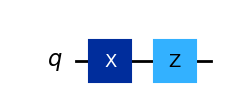

Counts: {'1': 2000}


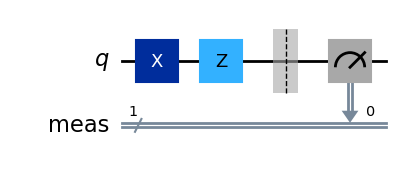

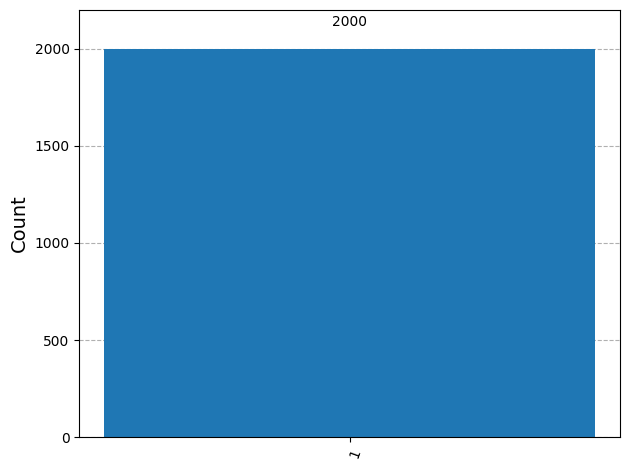

{'1': 2000}

In [12]:
qc = QuantumCircuit(1, name='Z')
qc.x(0)  # prepare |1>
qc.z(0)
demo(qc, 'Z gate acting on |1> (phase becomes -1)')

### Hadamard (H)
Creates superposition: H|0⟩ = |+⟩ = (|0⟩ + |1⟩)/√2.


=== H gate (expect ~50/50) ===
Statevector (before measurement):
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


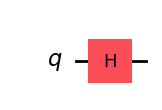

Counts: {'1': 983, '0': 1017}


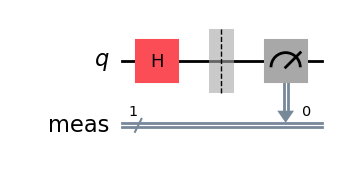

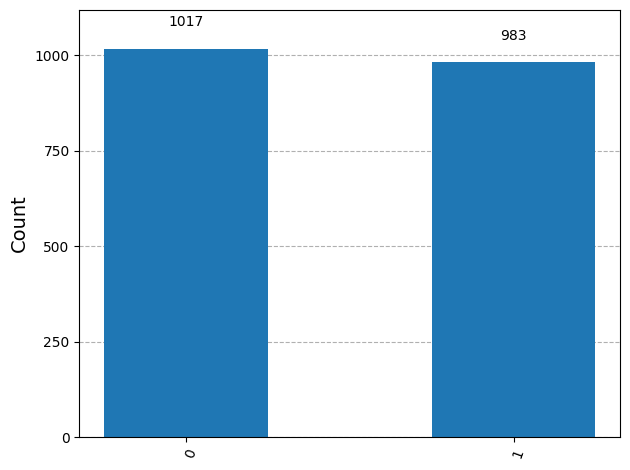

{'1': 983, '0': 1017}

In [13]:
qc = QuantumCircuit(1, name='H')
qc.h(0)
demo(qc, 'H gate (expect ~50/50)')

### Phase gates: S, S†, T, T†
These are Z-axis phase rotations:
- S = Rz(π/2)
- T = Rz(π/4)
They change **relative phase**, which is visible in the statevector (and in interference), not necessarily in Z-basis counts.


=== S gate on |+> ===
Statevector (before measurement):
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


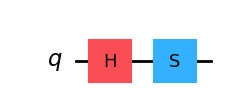

Counts: {'0': 992, '1': 1008}


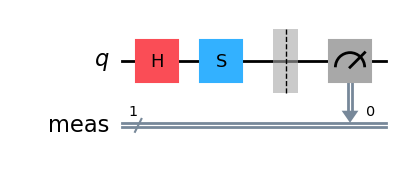

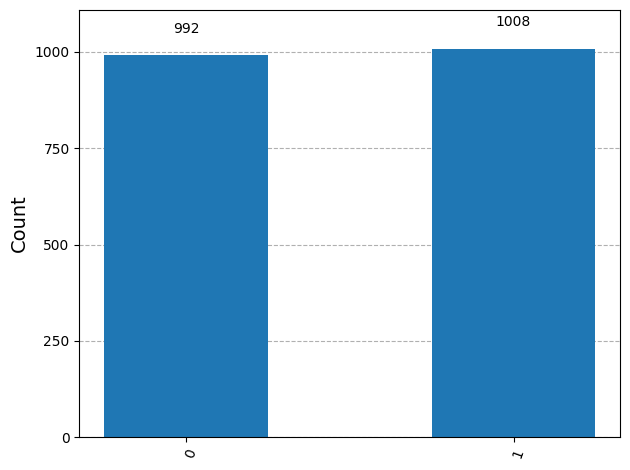


=== T gate on |+> ===
Statevector (before measurement):
Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


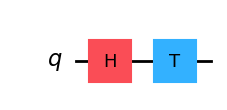

Counts: {'0': 1042, '1': 958}


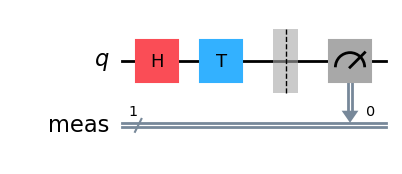

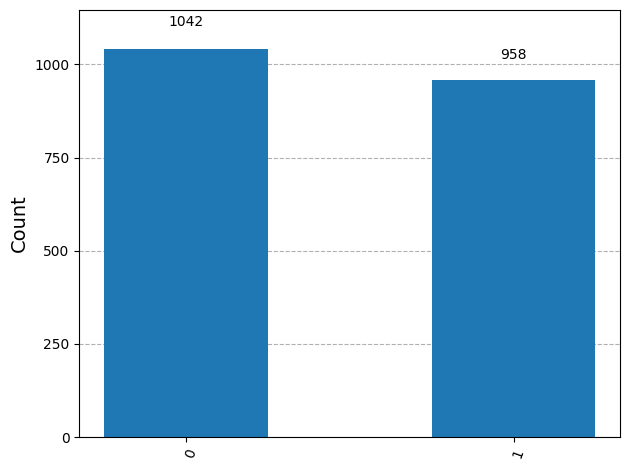


=== S† (Sdg) on |+> ===
Statevector (before measurement):
Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


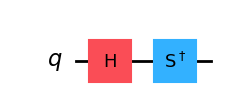

Counts: {'1': 996, '0': 1004}


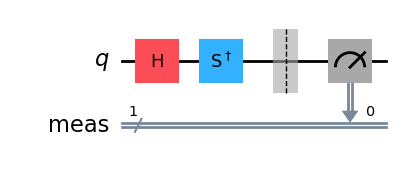

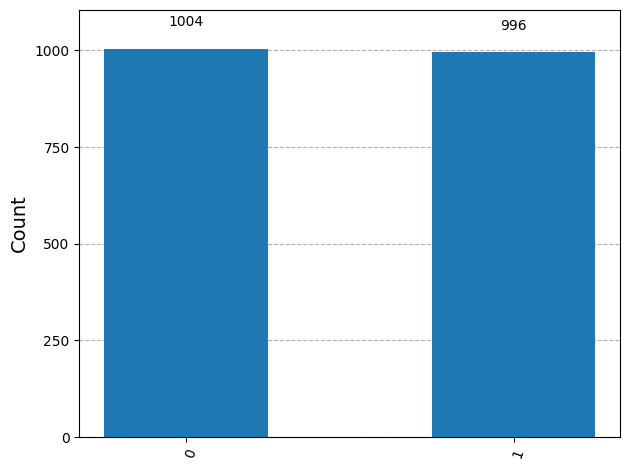


=== T† (Tdg) on |+> ===
Statevector (before measurement):
Statevector([0.70710678+0.j , 0.5       -0.5j],
            dims=(2,))


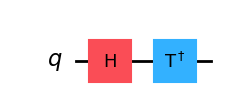

Counts: {'1': 994, '0': 1006}


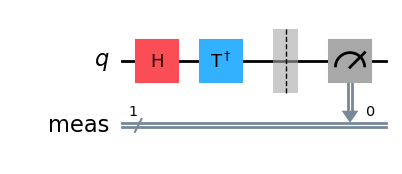

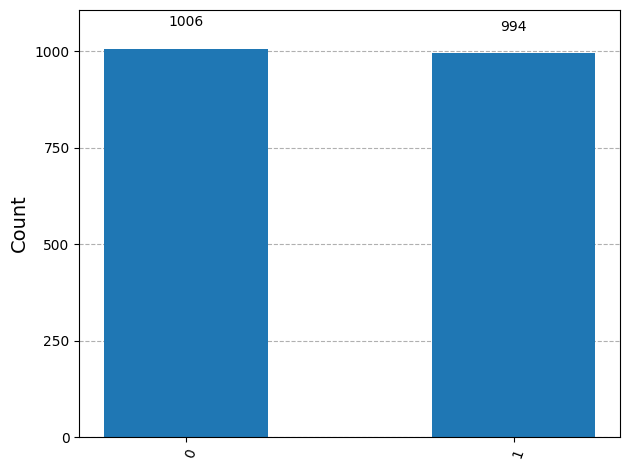

{'1': 994, '0': 1006}

In [14]:
qc = QuantumCircuit(1, name='S on |+>')
qc.h(0)
qc.s(0)
demo(qc, 'S gate on |+>')

qc = QuantumCircuit(1, name='T on |+>')
qc.h(0)
qc.t(0)
demo(qc, 'T gate on |+>')

qc = QuantumCircuit(1, name='Sdg on |+>')
qc.h(0)
qc.sdg(0)
demo(qc, 'S† (Sdg) on |+>')

qc = QuantumCircuit(1, name='Tdg on |+>')
qc.h(0)
qc.tdg(0)
demo(qc, 'T† (Tdg) on |+>')

### Rotation gates: Rx, Ry, Rz
Continuous rotations around Bloch-sphere axes. Examples below use θ = π/2.


=== Rx(pi/2) ===
Statevector (before measurement):
Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


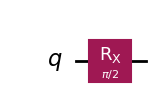

Counts: {'1': 988, '0': 1012}


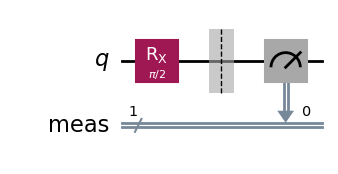

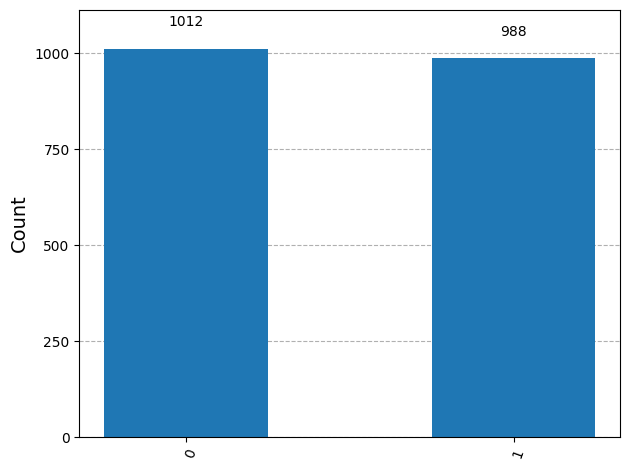


=== Ry(pi/2) ===
Statevector (before measurement):
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


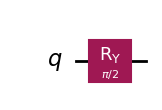

Counts: {'0': 979, '1': 1021}


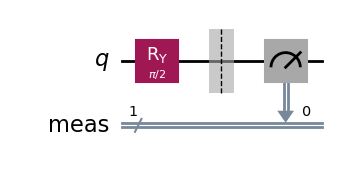

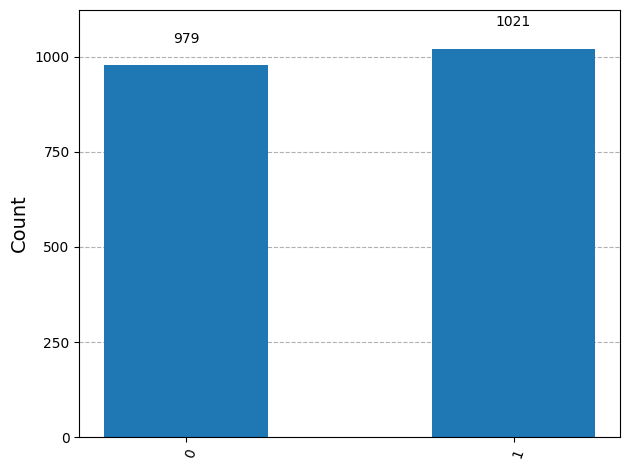


=== Rz(pi/2) on |+> ===
Statevector (before measurement):
Statevector([0.5-0.5j, 0.5+0.5j],
            dims=(2,))


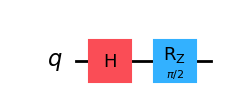

Counts: {'0': 989, '1': 1011}


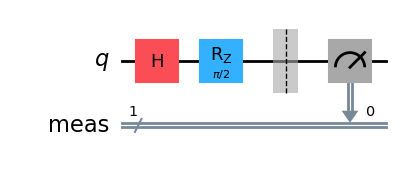

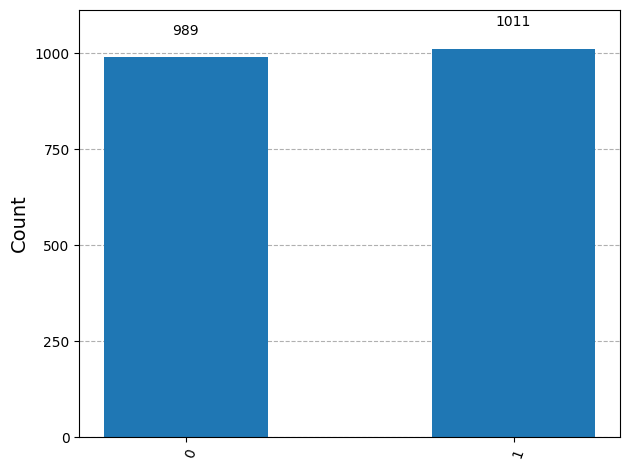

{'0': 989, '1': 1011}

In [15]:
theta = np.pi / 2

qc = QuantumCircuit(1, name='Rx')
qc.rx(theta, 0)
demo(qc, 'Rx(pi/2)')

qc = QuantumCircuit(1, name='Ry')
qc.ry(theta, 0)
demo(qc, 'Ry(pi/2)')

qc = QuantumCircuit(1, name='Rz')
qc.h(0)  # put into superposition so phase matters
qc.rz(theta, 0)
demo(qc, 'Rz(pi/2) on |+>')

### Phase shift (P) and general U gate
- `p(λ)` applies a phase e^{iλ} to |1⟩.
- `u(θ, φ, λ)` is a general single-qubit unitary used by Qiskit (sometimes called U3 in older literature).


=== P(pi/3) on |+> ===
Statevector (before measurement):
Statevector([0.70710678+0.j        , 0.35355339+0.61237244j],
            dims=(2,))


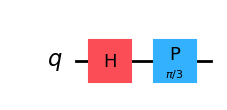

Counts: {'0': 989, '1': 1011}


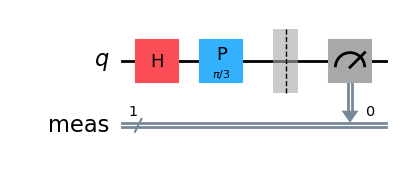

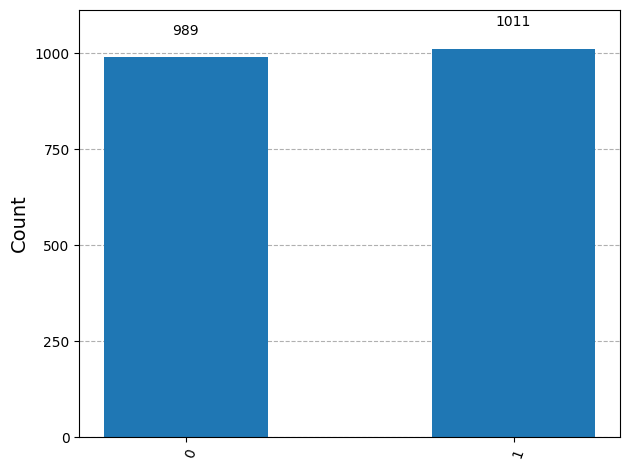


=== U(theta, phi, lambda) example ===
Statevector (before measurement):
Statevector([0.70710678+0.j        , 0.35355339+0.61237244j],
            dims=(2,))


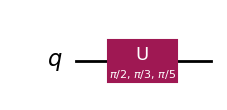

Counts: {'0': 965, '1': 1035}


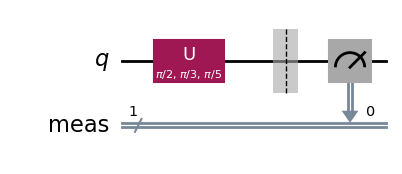

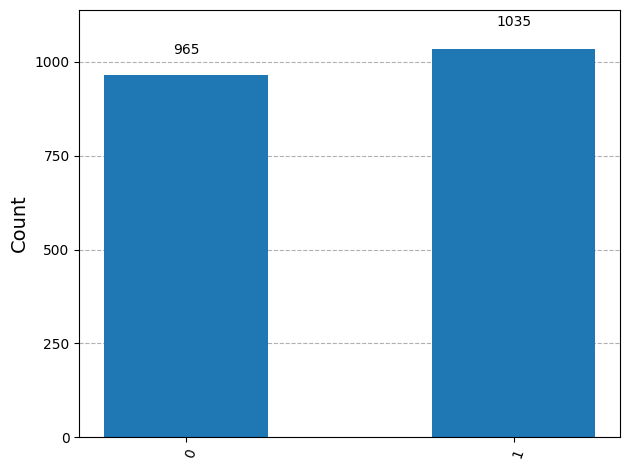

{'0': 965, '1': 1035}

In [16]:
qc = QuantumCircuit(1, name='P')
qc.h(0)
qc.p(np.pi/3, 0)
demo(qc, 'P(pi/3) on |+>')

qc = QuantumCircuit(1, name='U')
qc.u(np.pi/2, np.pi/3, np.pi/5, 0)
demo(qc, 'U(theta, phi, lambda) example')

## 2-qubit (and multi-qubit) gates

### Controlled-NOT (CX)
Flips the target when control is 1. Together with H, it can create entanglement (Bell state).


=== Bell state via H + CX (expect mostly 00 and 11) ===
Statevector (before measurement):
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


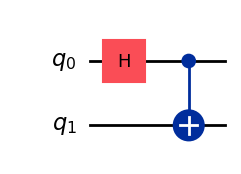

Counts: {'11': 997, '00': 1003}


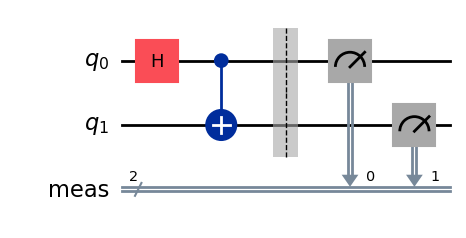

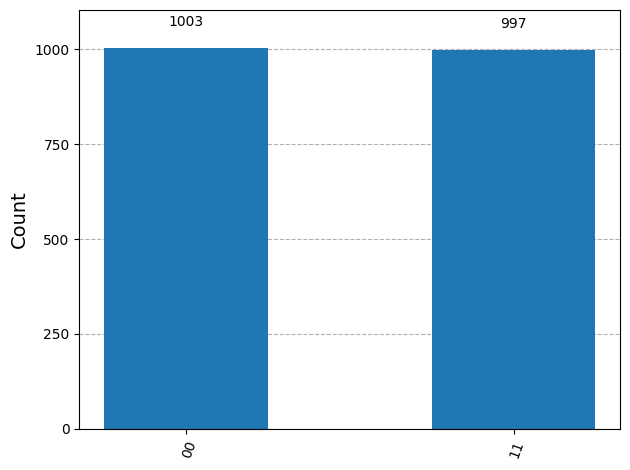

{'11': 997, '00': 1003}

In [17]:
qc = QuantumCircuit(2, name='Bell')
qc.h(0)
qc.cx(0, 1)
demo(qc, 'Bell state via H + CX (expect mostly 00 and 11)')

### Controlled-Z (CZ)
Applies a Z phase to the target when control is 1. It’s diagonal, so phase changes may not show up in Z-basis counts unless you interfere.


=== CZ on |++> (phase changes in statevector) ===
Statevector (before measurement):
Statevector([ 0.5+0.j,  0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))


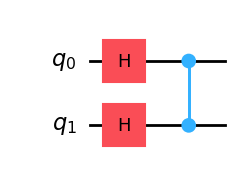

Counts: {'00': 502, '01': 499, '11': 496, '10': 503}


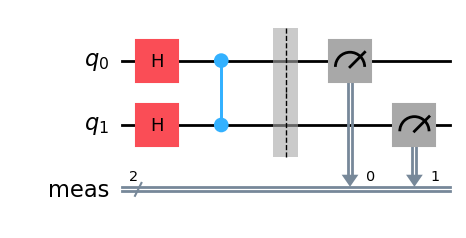

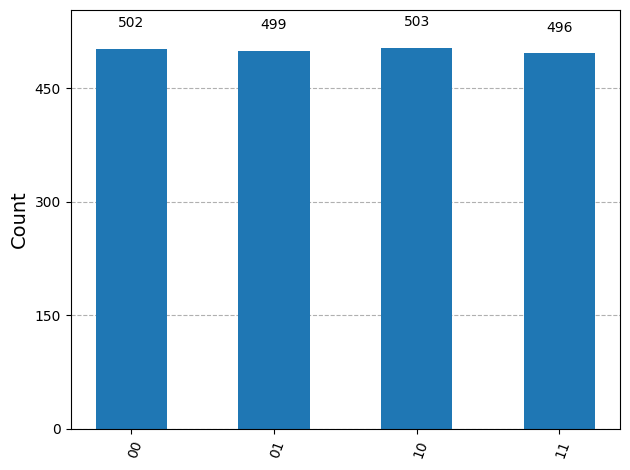

{'00': 502, '01': 499, '11': 496, '10': 503}

In [18]:
qc = QuantumCircuit(2, name='CZ')
qc.h(0)
qc.h(1)
qc.cz(0, 1)
demo(qc, 'CZ on |++> (phase changes in statevector)')

### Controlled-Y (CY) and Controlled-H (CH)
More controlled single-qubit gates.


=== CY with control prepared as |1> ===
Statevector (before measurement):
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+1.j],
            dims=(2, 2))


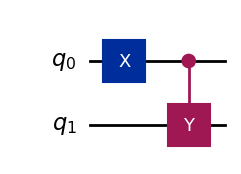

Counts: {'11': 2000}


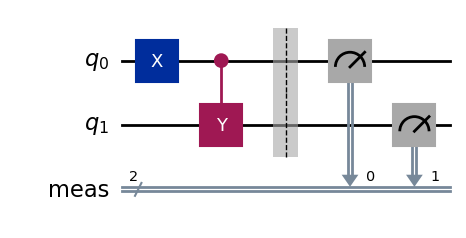

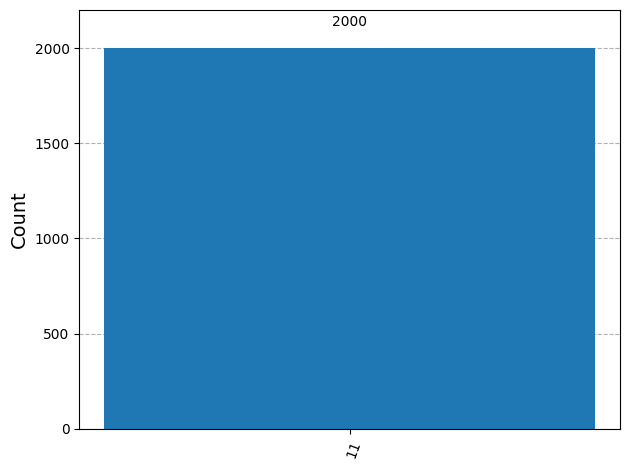


=== CH with control prepared as |1> ===
Statevector (before measurement):
Statevector([0.        +0.j, 0.70710678+0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


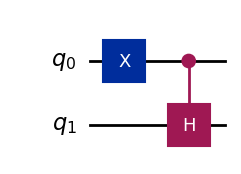

Counts: {'11': 1014, '01': 986}


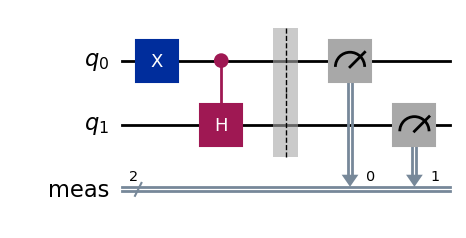

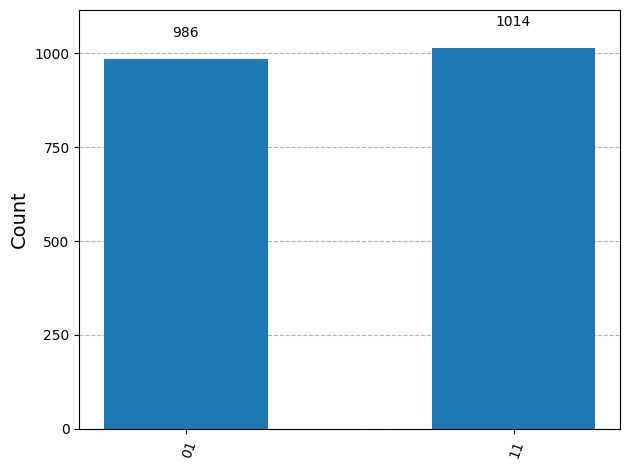

{'11': 1014, '01': 986}

In [19]:
qc = QuantumCircuit(2, name='CY')
qc.x(0)       # control = 1
qc.cy(0, 1)   # apply Y to target
demo(qc, 'CY with control prepared as |1>')

qc = QuantumCircuit(2, name='CH')
qc.x(0)       # control = 1
qc.ch(0, 1)   # apply H to target
demo(qc, 'CH with control prepared as |1>')

### Controlled phase (CP)
Applies a phase e^{iλ} to the |11⟩ component.


=== CP(pi/2) on |++> ===
Statevector (before measurement):
Statevector([5.000000e-01+0.j , 5.000000e-01+0.j , 5.000000e-01+0.j ,
             3.061617e-17+0.5j],
            dims=(2, 2))


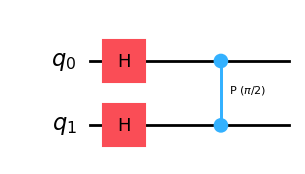

Counts: {'00': 488, '10': 487, '01': 497, '11': 528}


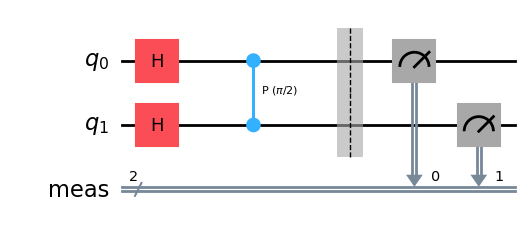

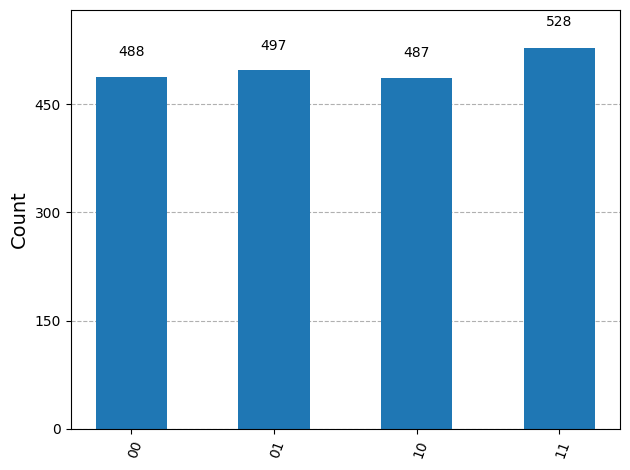

{'00': 488, '10': 487, '01': 497, '11': 528}

In [20]:
qc = QuantumCircuit(2, name='CP')
qc.h(0)
qc.h(1)
qc.cp(np.pi/2, 0, 1)
demo(qc, 'CP(pi/2) on |++>')

### SWAP
Swaps the states of two qubits.


=== SWAP: |01> -> |10> ===
Statevector (before measurement):
Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


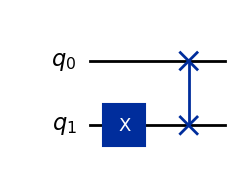

Counts: {'01': 2000}


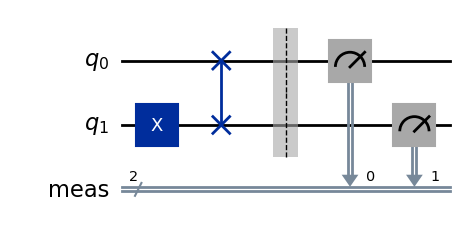

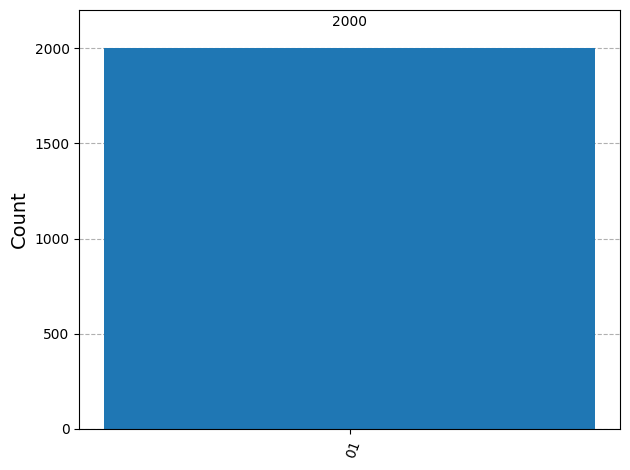

{'01': 2000}

In [21]:
qc = QuantumCircuit(2, name='SWAP')
qc.x(1)        # prepare |01>
qc.swap(0, 1)   # becomes |10>
demo(qc, 'SWAP: |01> -> |10>', show_statevector=True)

### Toffoli (CCX)
A 3-qubit controlled-controlled-X. Flips the target if **both** controls are 1.


=== CCX (Toffoli): controls=11 flips target ===
Statevector (before measurement):
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             1.+0.j],
            dims=(2, 2, 2))


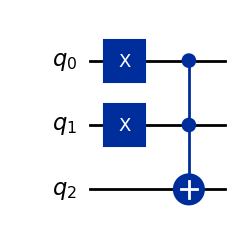

Counts: {'111': 2000}


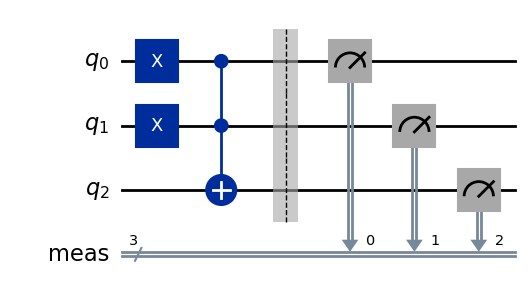

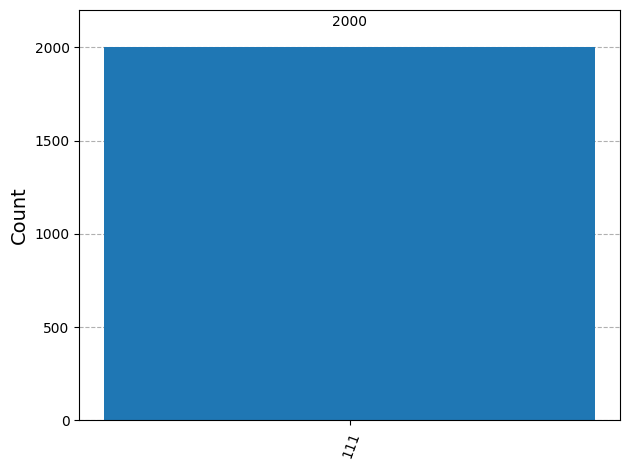

{'111': 2000}

In [22]:
qc = QuantumCircuit(3, name='CCX')
qc.x(0)
qc.x(1)         # controls = 1
qc.ccx(0, 1, 2)  # target flips
demo(qc, 'CCX (Toffoli): controls=11 flips target')

### Controlled-SWAP (CSWAP / Fredkin)
Swaps two target qubits if the control qubit is 1.


=== CSWAP: with control=1 swaps the last two qubits ===
Statevector (before measurement):
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


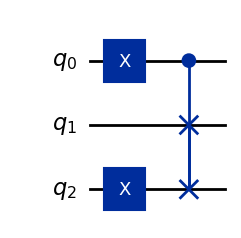

Counts: {'011': 2000}


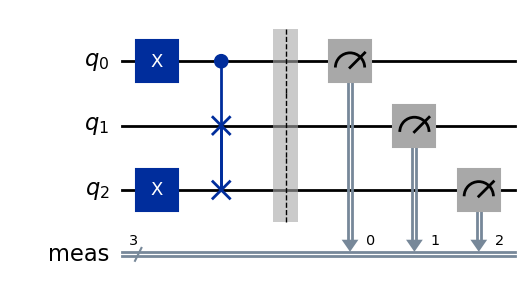

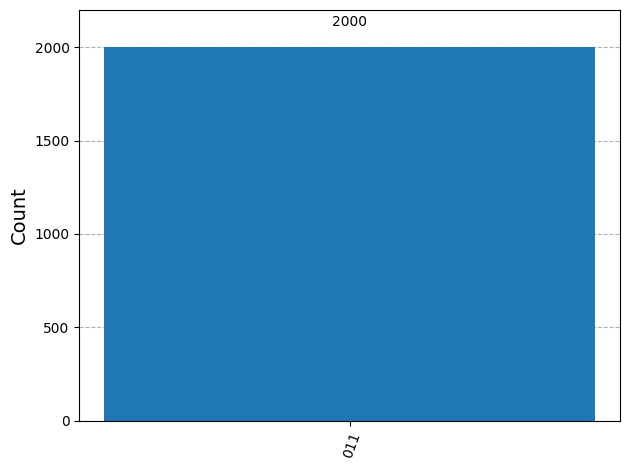

{'011': 2000}

In [23]:
qc = QuantumCircuit(3, name='CSWAP')
qc.x(0)      # control=1
qc.x(2)      # prepare |101> (targets are qubit1=0, qubit2=1)
qc.cswap(0, 1, 2)
demo(qc, 'CSWAP: with control=1 swaps the last two qubits')

## Non-unitary operations (not gates)
Measurement and reset are essential circuit operations, but they are **not** unitary gates.

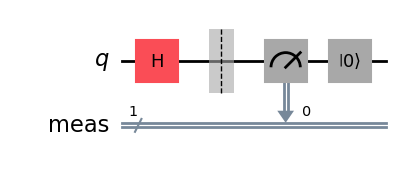

Counts: {'0': 992, '1': 1008}


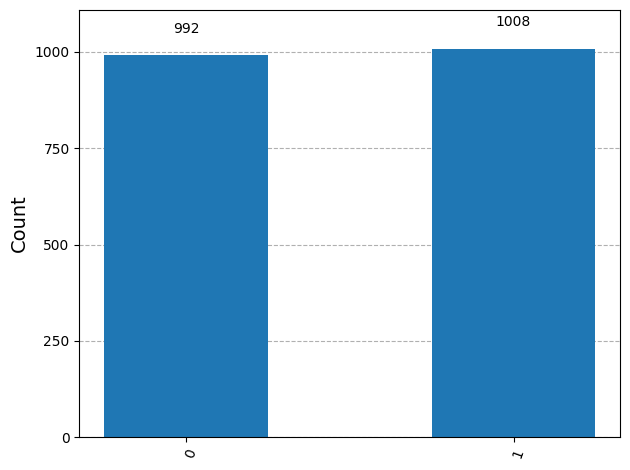

In [24]:
qc = QuantumCircuit(1, name='Measure + Reset')
qc.h(0)
qc.measure_all()
# Reset forces the qubit back to |0> (shown here after measurement for demonstration)
qc.reset(0)
display(qc.draw('mpl'))
tqc = transpile(qc, simulator)
result = simulator.run(tqc, shots=2000).result()
counts = result.get_counts()
print('Counts:', counts)
display(plot_histogram(counts))

## Quantum Teleportation (Alice → Bob)

Goal: teleport an *unknown* single-qubit state |ψ⟩ from **Alice** to **Bob** using:

- 1 shared entangled Bell pair (between Alice and Bob)
- 2 classical bits sent from Alice to Bob
- Conditional corrections (X/Z) applied by Bob

Qubit roles in the circuit:
- q0: Alice’s message qubit (the state |ψ⟩ to teleport)
- q1: Alice’s half of the Bell pair
- q2: Bob’s half of the Bell pair (receives |ψ⟩)

Input |ψ⟩ statevector: Statevector([0.74317106-0.50843068j, 0.35899255+0.24560002j],
            dims=(2,))
Fidelity (unitary/deferred check) between Bob and input: 1.000000


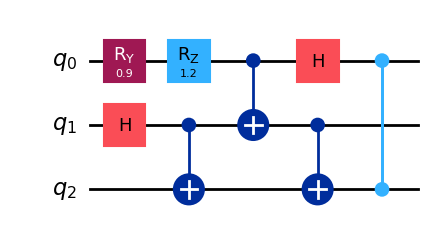

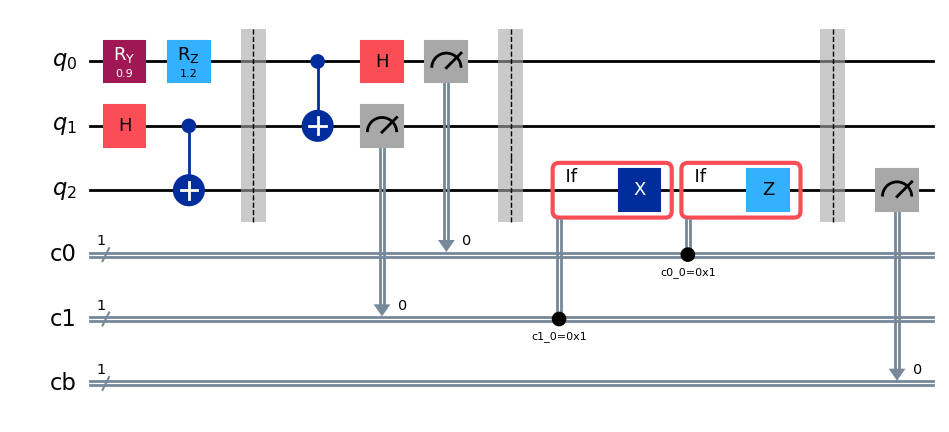

Raw counts (all classical bits): {'0 0 0': 797, '0 0 1': 854, '1 1 0': 186, '0 1 1': 813, '1 0 1': 197, '0 1 0': 797, '1 0 0': 160, '1 1 1': 196}
Bob counts (Z basis only): {'0': 3261, '1': 739}


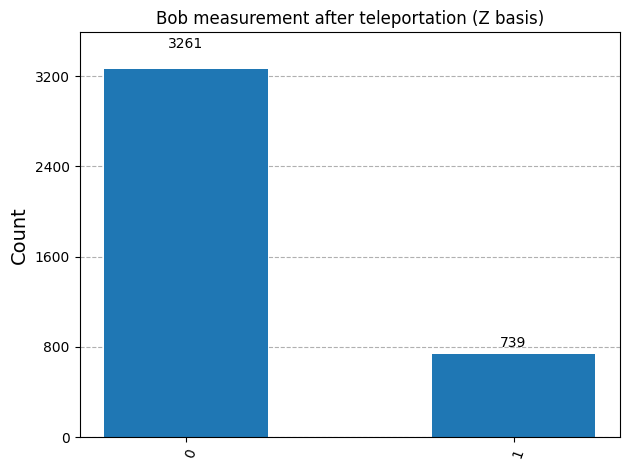

Expected P(0)=0.8108, P(1)=0.1892
Bob counts (X basis): {'0': 2568, '1': 1432}


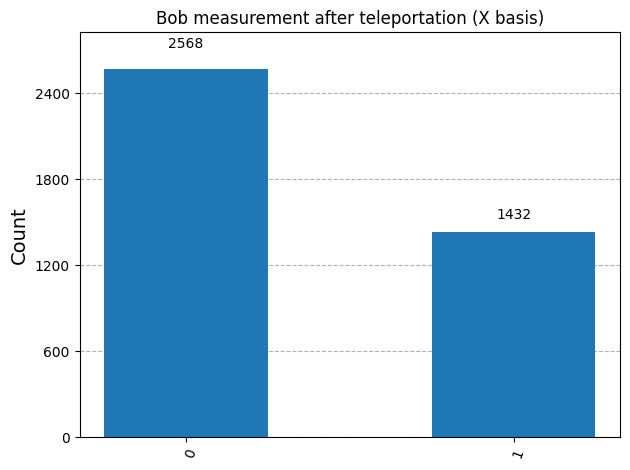

In [27]:
# Quantum Teleportation: implementation + verification
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.result import marginal_counts
import numpy as np
from IPython.display import display

# Choose an arbitrary single-qubit state |ψ⟩ to teleport (has amplitude + phase)
theta = 0.9  # rotation around Y
phi = 1.2    # rotation around Z (phase)

# Build |ψ⟩ on a single qubit (for reference)
psi_prep = QuantumCircuit(1, name='|ψ⟩ prep')
psi_prep.ry(theta, 0)
psi_prep.rz(phi, 0)
psi = Statevector.from_instruction(psi_prep)
print('Input |ψ⟩ statevector:', psi)

# --- 1) Verification via deferred measurement (purely unitary circuit) ---
# This uses the deferred-measurement principle to avoid mid-circuit measurement,
# so we can verify with an exact statevector simulation.
qc_unitary = QuantumCircuit(3, name='Teleport (unitary check)')
qc_unitary.ry(theta, 0)
qc_unitary.rz(phi, 0)

# Create Bell pair between q1 (Alice) and q2 (Bob)
qc_unitary.h(1)
qc_unitary.cx(1, 2)

# Alice's Bell-basis measurement steps (but we do NOT measure here)
qc_unitary.cx(0, 1)
qc_unitary.h(0)

# Bob's corrections, done coherently instead of classically (deferred measurement)
qc_unitary.cx(1, 2)  # corresponds to X correction controlled by Alice's 2nd bit
qc_unitary.cz(0, 2)  # corresponds to Z correction controlled by Alice's 1st bit

sv = Statevector.from_instruction(qc_unitary)
rho_bob = partial_trace(sv, [0, 1])  # trace out Alice's qubits
fid = state_fidelity(rho_bob, psi)
print(f'Fidelity (unitary/deferred check) between Bob and input: {fid:.6f}')
display(qc_unitary.draw('mpl'))

# --- 2) Actual teleportation circuit (measurements + classical communication) ---
q = QuantumRegister(3, 'q')
c0 = ClassicalRegister(1, 'c0')  # Alice measurement bit 0 (from q0)
c1 = ClassicalRegister(1, 'c1')  # Alice measurement bit 1 (from q1)
cb = ClassicalRegister(1, 'cb')  # Bob measurement (for checking)
qc = QuantumCircuit(q, c0, c1, cb, name='Teleport (Alice/Bob)')

# (A) Alice prepares the unknown state on q0
qc.ry(theta, q[0])
qc.rz(phi, q[0])

# (B) Create shared entanglement between Alice (q1) and Bob (q2)
qc.h(q[1])
qc.cx(q[1], q[2])
qc.barrier()

# (C) Alice performs Bell-basis measurement on (q0, q1)
qc.cx(q[0], q[1])
qc.h(q[0])
qc.measure(q[0], c0[0])
qc.measure(q[1], c1[0])
qc.barrier()

# (D) Bob applies corrections based on Alice's two classical bits
with qc.if_test((c1[0], 1)):
    qc.x(q[2])
with qc.if_test((c0[0], 1)):
    qc.z(q[2])
qc.barrier()

# Check by measuring Bob in Z basis
qc.measure(q[2], cb[0])
display(qc.draw('mpl'))

tqc = transpile(qc, simulator)
res = simulator.run(tqc, shots=4000).result()
counts = res.get_counts()
print('Raw counts (all classical bits):', counts)

# Extract Bob-only counts (classical bit index 2 because clbits are [c0[0], c1[0], cb[0]])
bob_counts = marginal_counts(counts, indices=[2])
print('Bob counts (Z basis only):', bob_counts)
display(plot_histogram(bob_counts, title='Bob measurement after teleportation (Z basis)'))

# Compare with the expected Z-basis probabilities of |ψ⟩
p0, p1 = psi.probabilities()  # [P(0), P(1)]
print(f'Expected P(0)={p0:.4f}, P(1)={p1:.4f}')

# Optional: measure Bob in X basis too (detects phase information)
qc_x = QuantumCircuit(q, c0, c1, cb, name='Teleport + X-basis check')
qc_x.ry(theta, q[0])
qc_x.rz(phi, q[0])
qc_x.h(q[1])
qc_x.cx(q[1], q[2])
qc_x.cx(q[0], q[1])
qc_x.h(q[0])
qc_x.measure(q[0], c0[0])
qc_x.measure(q[1], c1[0])
with qc_x.if_test((c1[0], 1)):
    qc_x.x(q[2])
with qc_x.if_test((c0[0], 1)):
    qc_x.z(q[2])
qc_x.h(q[2])              # rotate X basis -> Z basis
qc_x.measure(q[2], cb[0])

tqc_x = transpile(qc_x, simulator)
res_x = simulator.run(tqc_x, shots=4000).result()
counts_x = res_x.get_counts()
bob_counts_x = marginal_counts(counts_x, indices=[2])
print('Bob counts (X basis):', bob_counts_x)
display(plot_histogram(bob_counts_x, title='Bob measurement after teleportation (X basis)'))